In [111]:
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List, Literal, Optional
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.types import Send
from langchain_tavily import TavilySearch
import operator
from pathlib import Path
from dotenv import load_dotenv
import os

In [112]:
import os
from langchain_tavily import TavilyExtract


# Instantiate the extract tool
extract_tool = TavilyExtract(
    extract_depth="advanced", # Options: "basic" or "advanced"
    format="markdown"        # Options: "markdown" or "text"
)

# Extract content from target URLs
extracted_data = extract_tool.invoke({
    "urls": [
        "https://python.langchain.com/docs/introduction/",
        "https://docs.tavily.com/documentation/overview"
    ]
})

print(extracted_data)

{'results': [{'url': 'https://python.langchain.com/docs/introduction/', 'title': 'LangChain overview - Docs by LangChain', 'raw_content': '> ## Documentation Index\n>\n> Fetch the complete documentation index at:</llms.txt>\n>\n> Use this file to discover all available pages before exploring further.\n\nInterrupt is coming to NYC and London this fall. Join the builders, engineers, and teams shaping what\'s next for agents. [Get your tickets →](https://interrupt.langchain.com/)\n\n[Docs by LangChain home page](/)\n\n[Overview](/build-overview)[Deep Agents](/oss/python/deepagents/overview)[LangChain](/oss/python/langchain/overview)[LangGraph](/oss/python/langgraph/overview)[Integrations](/oss/python/integrations/providers/overview)[Learn](/oss/python/learn)[Reference](/oss/python/reference/overview)[Contribute](/oss/python/contributing/overview)\n\n# LangChain overview\n\nLangChain provides create\\_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use c

In [113]:
load_dotenv()

tavily = TavilySearch(
    max_result =5,
    search_depth = 'advanced',
    topic = 'general'
)

results = tavily.invoke(
    {
        'query': 'Latest News on LangGraph'
    }
)
results

{'query': 'Latest News on LangGraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://thehackernews.com/2026/06/langgraph-flaw-chain-exposes-self.html',
   'title': 'LangGraph Flaw Chain Exposes Self-Hosted AI Agents to ...',
   'content': '#1 Trusted Cybersecurity News Platform\n\nFollowed by 5.70+ million\uf099 \uf0e1 \uf09a\n\nThe Hacker News Logo\n\n\uf0e0 Get the Latest News\n\ncybersecurity\n\n# LangGraph Flaw Chain Exposes Self-Hosted AI Agents to Remote Code Execution\n\n\ue804Ravie Lakshmanan\ue802Jun 12, 2026Vulnerability / AI Security\n\n agentic applications.\n\n"An SQL injection in LangGraph\'s function could allow attackers to gain full control via remote code execution of a server by exploiting weaknesses in how the system processes and handles data," Check Point said.\n\nThe list of identified vulnerabilities is as follows - [...] CVE-2025-67644 (CVSS score: 7.3) - A SQL injection vulnerability exists in LangGraph\'s SQLite ch

In [114]:
for r in results['results']:
    print(r['title'])

LangGraph Flaw Chain Exposes Self-Hosted AI Agents to ...
LangGraph | Technology Radar | Thoughtworks United States
LangGraph Platform and Studio: The Future of AI Agent Development
Medium
Releases · langchain-ai/langgraph


In [115]:
os.environ['LANGCHAIN_PROJECT'] = 'BLOG_WRITING_AGENT_CREATION'

In [116]:
load_dotenv()


llm = ChatOpenAI(
    model="openai/gpt-oss-120b",
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1",
)

In [117]:
class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)

## Standadized Format from Tavily Search Results

In [118]:
class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # keep if Tavily provides; DO NOT rely on it
    snippet: Optional[str] = None
    source: Optional[str] = None


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)

In [119]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        default="Explain the key concepts of this section clearly.",
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        default_factory=list,
        description="3–6 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        default=300, 
        description="Target word count for this section (120–550)."
    )

    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False

In [120]:
class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]

In [121]:
class State(TypedDict):
    topic: str

    # routing / research
    mode: str # from routing decisoin
    needs_research: bool # from routing decisoin
    queries: List[str] # from routing decisoin
    evidence: List[EvidenceItem] # from research 
    plan: Optional[Plan] # From orchestrator

    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]  # (task_id, section_md)
    final: str

In [122]:
# -----------------------------
# 3) Router (decide upfront)
# -----------------------------
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3–10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

In [123]:
def router_node(state: State) -> dict:
    
    topic = state["topic"]
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}"),
        ]
    )

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
    }

def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"

### Temp Graph for testing Till Router

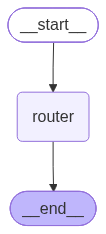

In [124]:
builder = StateGraph(State)

builder.add_node('router', router_node)

builder.add_edge(START, 'router')
builder.add_edge('router', END)

graph = builder.compile()
graph

In [125]:
graph.invoke(
    {
        'topic': 'Latest AI News'
    }
)

{'topic': 'Latest AI News',
 'mode': 'open_book',
 'needs_research': True,
 'queries': ['What AI research papers or preprints were released in the past week on arXiv that have over 10 citations or significant media coverage?',
  'Which major AI companies (e.g., OpenAI, Google DeepMind, Anthropic, Meta AI) announced new model releases, product updates, or partnerships in the last 7 days?',
  'What new AI tools, APIs, or platforms were launched or entered beta in the past week, including details on their capabilities and pricing models?',
  'Were there any notable AI-related regulatory or policy changes announced by governments or international bodies in the last week?',
  'What major AI conferences or industry events took place in the past seven days, and what key announcements or breakthrough demos were presented?',
  'Which AI startups received significant funding rounds or acquisitions announced within the last week, and what technologies are they focusing on?',
  'What trending AI d

In [126]:
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:

    tool = TavilySearch(
        max_result =5,
        search_depth = 'advanced',
        topic = 'general'
    )
    
    results = tool.invoke({"query": query})

    normalized: List[dict] = []
    for r in results['results'] or []:
        normalized.append(
            {
                "title": r.get('title') or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
            }
        )
    return normalized

In [127]:
RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""

In [128]:
def research_node(state: State) -> dict:

    # take the first 10 queries from state
    queries = (state.get("queries", []) or [])
    max_results = 6

    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content=f"Raw results:\n{raw_results}"),
        ]
    )

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    return {"evidence": list(dedup.values())}

In [129]:
# -----------------------------
# 5) Orchestrator (Plan)
# -----------------------------
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5–9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3–6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120–550)

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""

In [130]:
planner = llm.with_structured_output(Plan)

In [131]:
def orchestrator_node(state: State) -> dict:
    planner = llm.with_structured_output(Plan)

    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() for e in evidence]}"
                )
            ),
        ]
    )

    return {"plan": plan}

In [132]:
def fanout(state: State):
    """ 
    DYNAMIC FAN-OUT (Map-Reduce) ROUTER
    ====================================
    WHAT THIS DOES:
    - Fanning out means splitting a single workflow execution into multiple 
      parallel tasks that run concurrently.
      
    WHY WE USE IT HERE:
    - Instead of generating section content one task at a time (sequentially), 
      we iterate over all tasks in `state['plan'].tasks` and spawn a dedicated 
      'worker' node for each task simultaneously. This speeds up total runtime.

    WHAT `Send('worker', payload)` DOES:
    - `Send` is LangGraph's primitive for dynamic parallel execution.
    - Argument 1 ('worker'): Specifies the target destination node to run.
    - Argument 2 ({...}): The isolated dictionary (payload) sent into that worker's 
      individual state. Each parallel worker receives its own specific task data.
    """
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state["mode"],
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            },
        )
        for task in state["plan"].tasks
    ]

In [133]:
WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (±15%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard:
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true:
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""

In [134]:
def worker_node(payload: dict) -> dict:
    
    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]
    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")

    # Safe handling if bullets is empty
    bullets_text = "\n- " + "\n- ".join(task.bullets) if task.bullets else "\n- Cover the section main topic in detail."

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url}".strip()
            for e in evidence
        )

    section_md = llm.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task.id, section_md)]}

In [135]:

def reducer_node(state: State) -> dict:

    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    final_md = f"# {plan.blog_title}\n\n{body}\n"

    filename = f"{plan.blog_title}.md"
    Path(filename).write_text(final_md, encoding="utf-8")

    return {"final": final_md}

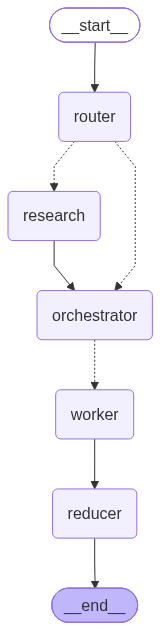

In [136]:
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [137]:
def run(topic: str):
    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
        }
    )

    return out

In [139]:
run("Latest AI news and major framework updates from this week"

"Recent developments in open-source LLMs in 2026?")

{'topic': 'Latest AI news and major framework updates from this weekRecent developments in open-source LLMs in 2026?',
 'mode': 'open_book',
 'needs_research': True,
 'queries': ['What open‑source large language models were released or significantly updated between July 24\u202f–\u202fJuly 31\u202f2026, including version numbers, model sizes, and licensing details?',
  'Which major AI framework (e.g., PyTorch, TensorFlow, JAX, MindSpore) released new stable versions or feature rollouts during the week of July\u202f24‑30\u202f2026, and what are the headline improvements (performance, APIs, hardware support)?',
  'What notable AI research papers or blog posts were published this week (July\u202f2026) that introduce novel training techniques, alignment methods, or inference optimizations for open‑source LLMs?',
  'Which leading cloud providers or hardware vendors announced updated pricing, support, or specialized accelerators for running open‑source LLMs in the last seven days, and how do